In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
def plot_results(fname) :
    df = pd.read_csv(fname)
    
    (df.pivot(index="number of calls",
              columns="binding",
              values="execution time")
       # .plot(marker="o", logx=True, logy=True))
    .plot(marker="o", logx=False, logy=False))
    
    plt.ylabel("Execution time [s]")
    plt.xlabel("Number of calls")
    plt.grid(True)
    plt.title(fname)
    plt.show()

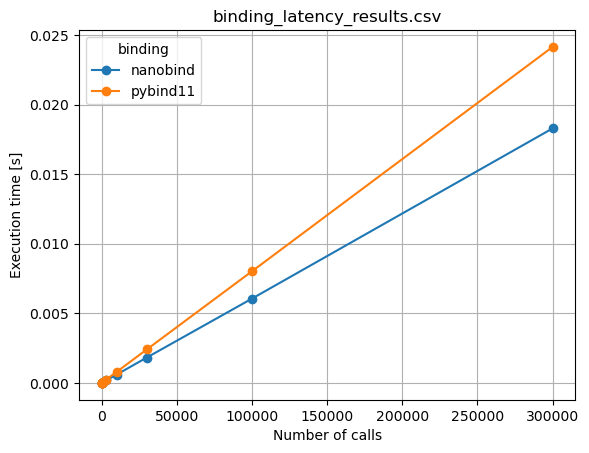

In [6]:
plot_results('binding_latency_results.csv')

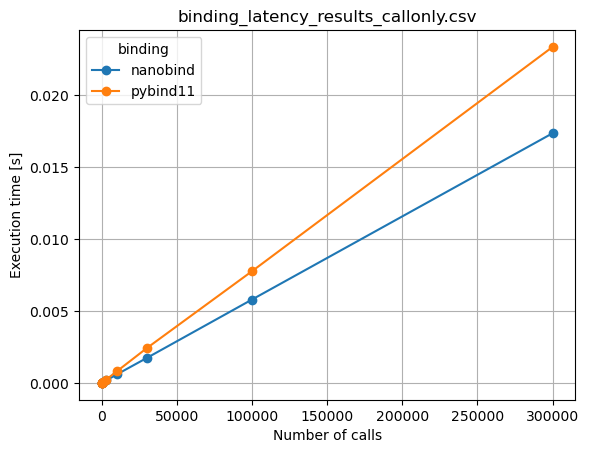

In [7]:
plot_results('binding_latency_results_callonly.csv')

In [5]:
from scipy.stats import linregress
df = pd.read_csv("binding_latency_results.csv")

results = []

for binding, group in df.groupby("binding"):
    fit = linregress(group["number of calls"], group["execution time"])

    results.append({
        "binding": binding,
        "slope": fit.slope,
        "intercept": fit.intercept,
        "r2": fit.rvalue**2,
        "pvalue": fit.pvalue
    })

    print(f"{binding}")
    print(f"  time = {fit.slope:.3e} * calls + {fit.intercept:.3e}")
    print(f"  R²   = {fit.rvalue**2:.6f}")

regression_df = pd.DataFrame(results)
print(regression_df)

nanobind
  time = 6.095e-08 * calls + -4.346e-06
  R²   = 0.999996
pybind11
  time = 8.047e-08 * calls + -4.239e-06
  R²   = 0.999999
    binding         slope  intercept        r2        pvalue
0  nanobind  6.094675e-08  -0.000004  0.999996  5.287162e-23
1  pybind11  8.047245e-08  -0.000004  0.999999  2.457389e-25


In [14]:
df = pd.read_csv("binding_latency_results.csv")
df['per call'] = df['execution time']/df['number of calls']

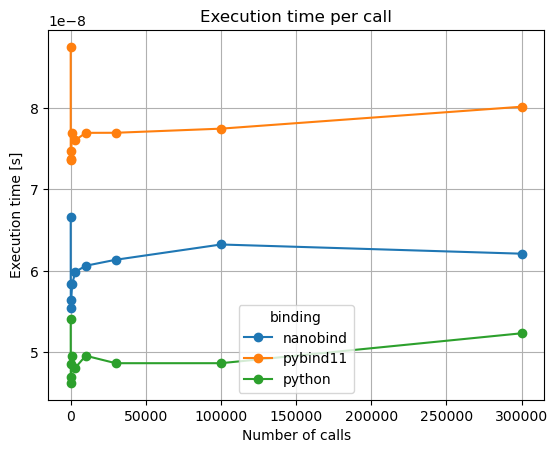

In [15]:
(df.pivot(index="number of calls",
          columns="binding",
          values="per call")
   # .plot(marker="o", logx=True, logy=True))
.plot(marker="o", logx=False, logy=False))

plt.ylabel("Execution time [s]")
plt.xlabel("Number of calls")
plt.grid(True)
plt.title('Execution time per call')
plt.show()